In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Wavelength of HeNe laser analysis

In [274]:
# manually input raw data
num_fringes = np.arange(20,220,20) # the number of fringes we counted

# need the factor of 2 to convert to micrometers
hene_data = 2.0 * np.array([
             [3.8, 7.1, 10.3, 13.3, 17.1, 20.2, 23.9, 26.8, 30.0, 33.0],
             [4.6, 7.9, 11.0, 14.6, 18.1, 21.9, 25.2, 28.6, 32.0, 35.2],
             [3.2, 5.9, 9.8, 12.9, 16.1, 19.5, 22.7, 25.9, 29.0, 32.9],
             [4.6, 7.5, 10.7, 14.0, 17.0, 20.3, 23.6, 26.7, 29.9, 33.4],
             [3.1, 5.2, 9.5, 12.8, 16.0, 19.2, 22.2, 25.7, 28.9, 32.1] ])

In [275]:
df = pd.DataFrame({'N_fringes':num_fringes, 'meas1':hene_data[0], 'meas2':hene_data[1],
                  'meas3':hene_data[2], 'meas4':hene_data[3], 'meas5':hene_data[4]})
# df.to_csv('hene_raw_data.csv')

In [276]:
# take the average and std of the independent measurement for each N number of fringes
hene_avg = np.mean(hene_data,axis=0)    
hene_std = np.std(hene_data,axis=0)
print(len(hene_avg), len(hene_std))

sys_err = np.sqrt(5 * 1.0**2) # systematic measurement error

10 10


In [277]:
new_fringes = np.copy(num_fringes)
for i in range(len(new_fringes)):
    new_fringes[i] = new_fringes[i] + (i + 1)

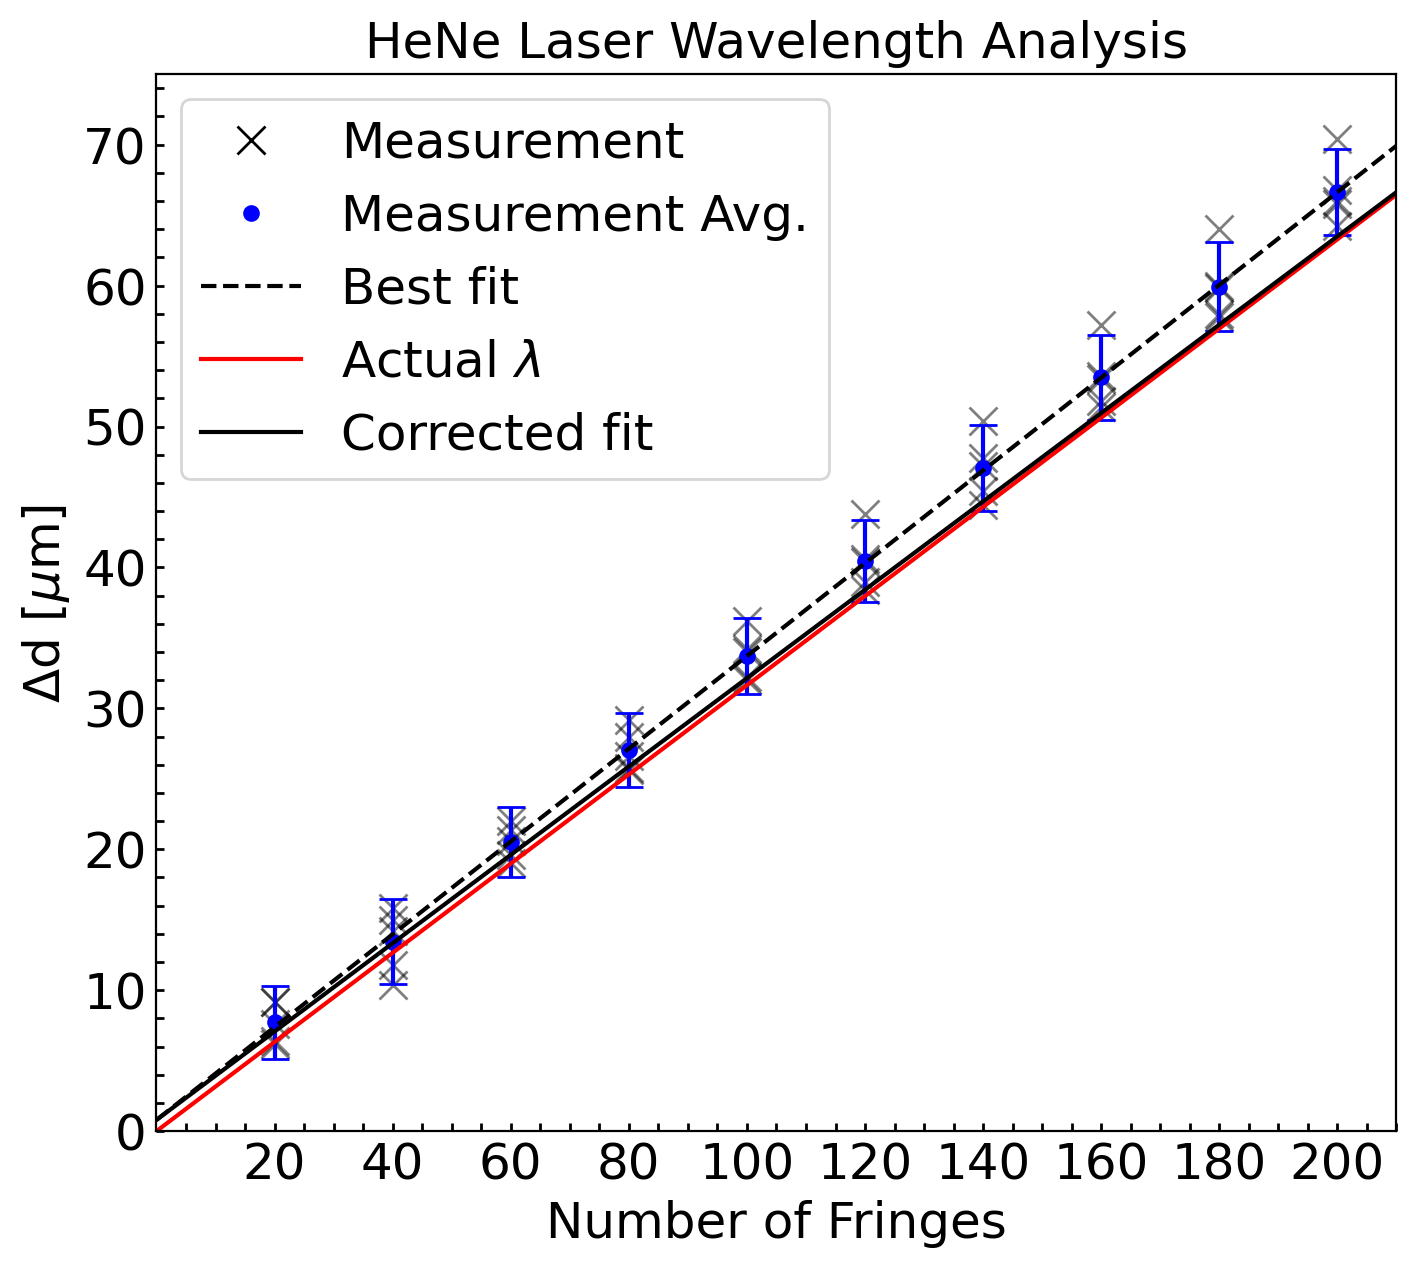

In [282]:
from scipy.optimize import curve_fit 

def f(x,m,b):
    return m * x + b

sigmas = np.sqrt(hene_std**2. + sys_err**2.)    # add the systematic and measurement error in quadrate
popt, pcov = curve_fit(f, num_fringes-110, hene_avg-37, sigma=sigmas)    # do the fit
# note, no error in x-axis since we counted the number of fringes, so only need to do the weighted fit once

fig = plt.figure(figsize=(8,7),dpi=200)
fs= 18

# plot the three measurement sets
plt.plot(num_fringes, hene_data[0], marker='x', markersize=10, ls='none', c='k', alpha=0.5)
plt.plot(num_fringes, hene_data[1], marker='x', markersize=10, ls='none', c='k', alpha=0.5)
plt.plot(num_fringes, hene_data[2], marker='x', markersize=10, ls='none', c='k', alpha=0.5)
plt.plot(num_fringes, hene_data[3], marker='x', markersize=10, ls='none', c='k', alpha=0.5)
plt.plot(num_fringes, hene_data[4], marker='x', markersize=10, ls='none', c='k', alpha=0.5)
plt.plot(100,100, marker='x', c='k', markersize=10, label='Measurement', ls='none')

# plot the avg and error
plt.plot(num_fringes, hene_avg, marker='o', markersize=5, color='b', ls='none', label='Measurement Avg.')
plt.errorbar(num_fringes, hene_avg, yerr=sigmas, capsize=5, color='b', ls='none')

# show the fit
xx = np.arange(0,220,10)
plt.plot(xx, popt[0] * (xx-110) + popt[1]+37, c='k', label='Best fit',ls='--')

# do the corrected fit assuming we missed 1 in every 20 fringes
popt_corr, pcov_corr = curve_fit(f, new_fringes-110, hene_avg-37, sigma=sigmas)
plt.plot(xx, popt_corr[0] * (xx-110) + popt_corr[1]+37, c='k', label='Corrected fit')

# show the actual wavelength
wv_real = 632.816 # nm
plt.plot(xx, wv_real/2e3 * xx, c='r', label='Actual $\lambda$')

# style points
plt.xlabel('Number of Fringes', fontsize=fs)
plt.ylabel('$\Delta$d [$\mu$m]', fontsize=fs)
plt.title('HeNe Laser Wavelength Analysis',fontsize=fs)
plt.xticks(num_fringes,fontsize=fs)
plt.yticks(fontsize=fs)
plt.ylim(0,75)
plt.xlim(0,210)
ax = fig.gca()
ax.minorticks_on()
ax.tick_params(which='both',direction='in', length=3, width=1, color='k')
plt.legend(fontsize=fs)

plt.savefig('HeNe_lambda_analysis.pdf',bbox_inches='tight')

In [279]:
# print best fit parameters and covariance
print(popt, pcov)

# and parameters for corrected fit
print(popt_corr, pcov_corr)

[0.32917612 0.00593625] [[1.73928829e-06 1.16261168e-05]
 [1.16261168e-05 5.65462917e-03]]


In [283]:
# calculate the wavelength and its error
wv = popt_corr[0] * 2 * 1e3 
wv_err = np.sqrt(np.diag(pcov_corr))[0] * 1e3

print('The wavelength is', round(wv,4), '+/-', round(wv_err,4), 'nm')

The wavelength is 627.0021 +/- 1.256 nm


In [287]:
# calculate the reduced chi2 of the fit
N = len(num_fringes)
Red_Chi2 = 1.0/(N-2) * np.sum((hene_avg - f(new_fringes, popt_corr[0],popt_corr[1]))**2 / sigmas**2)
print('Reduced Chi Squared= ', Red_Chi2)

Reduced Chi Squared=  0.9900474739929057


yay! 

## 1. Wavelength of alignment laser analysis

In [184]:
num_fringes = np.arange(20,220,20) # the number of fringes we counted

# load in the raw data and convert to micrometers
dd_C = np.array([3.0, 5.5, 9.0, 11.8, 14.2, 17.1, 19.9, 22.5, 25.0, 28.0]) * 2.0
dd_A = np.array([4.0, 6.3, 9.1, 11.7, 15.0, 17.9, 20.8, 23.8, 25.2, 28.0]) * 2.0
dd_J = np.array([3.5, 6.5, 9.2, 12.0, 14.9, 17.5, 20.1, 23.0, 25.9, 29.3]) * 2.0

In [185]:
df = pd.DataFrame({'N_fringe':num_fringes, 'dd_meas1':dd_C, 'dd_meas2':dd_A, 'dd_meas3':dd_J})
#df.to_csv('align_laser_meas.csv')

In [186]:
data_matrix = np.array((dd_C,dd_A,dd_J))
data_avg = np.mean(data_matrix,axis=0)    # take the average of the three sets of measurements
data_std = np.std(data_matrix,axis=0)     # and the std for weighted fit

sys_err = np.sqrt(3. * 0.5**2)

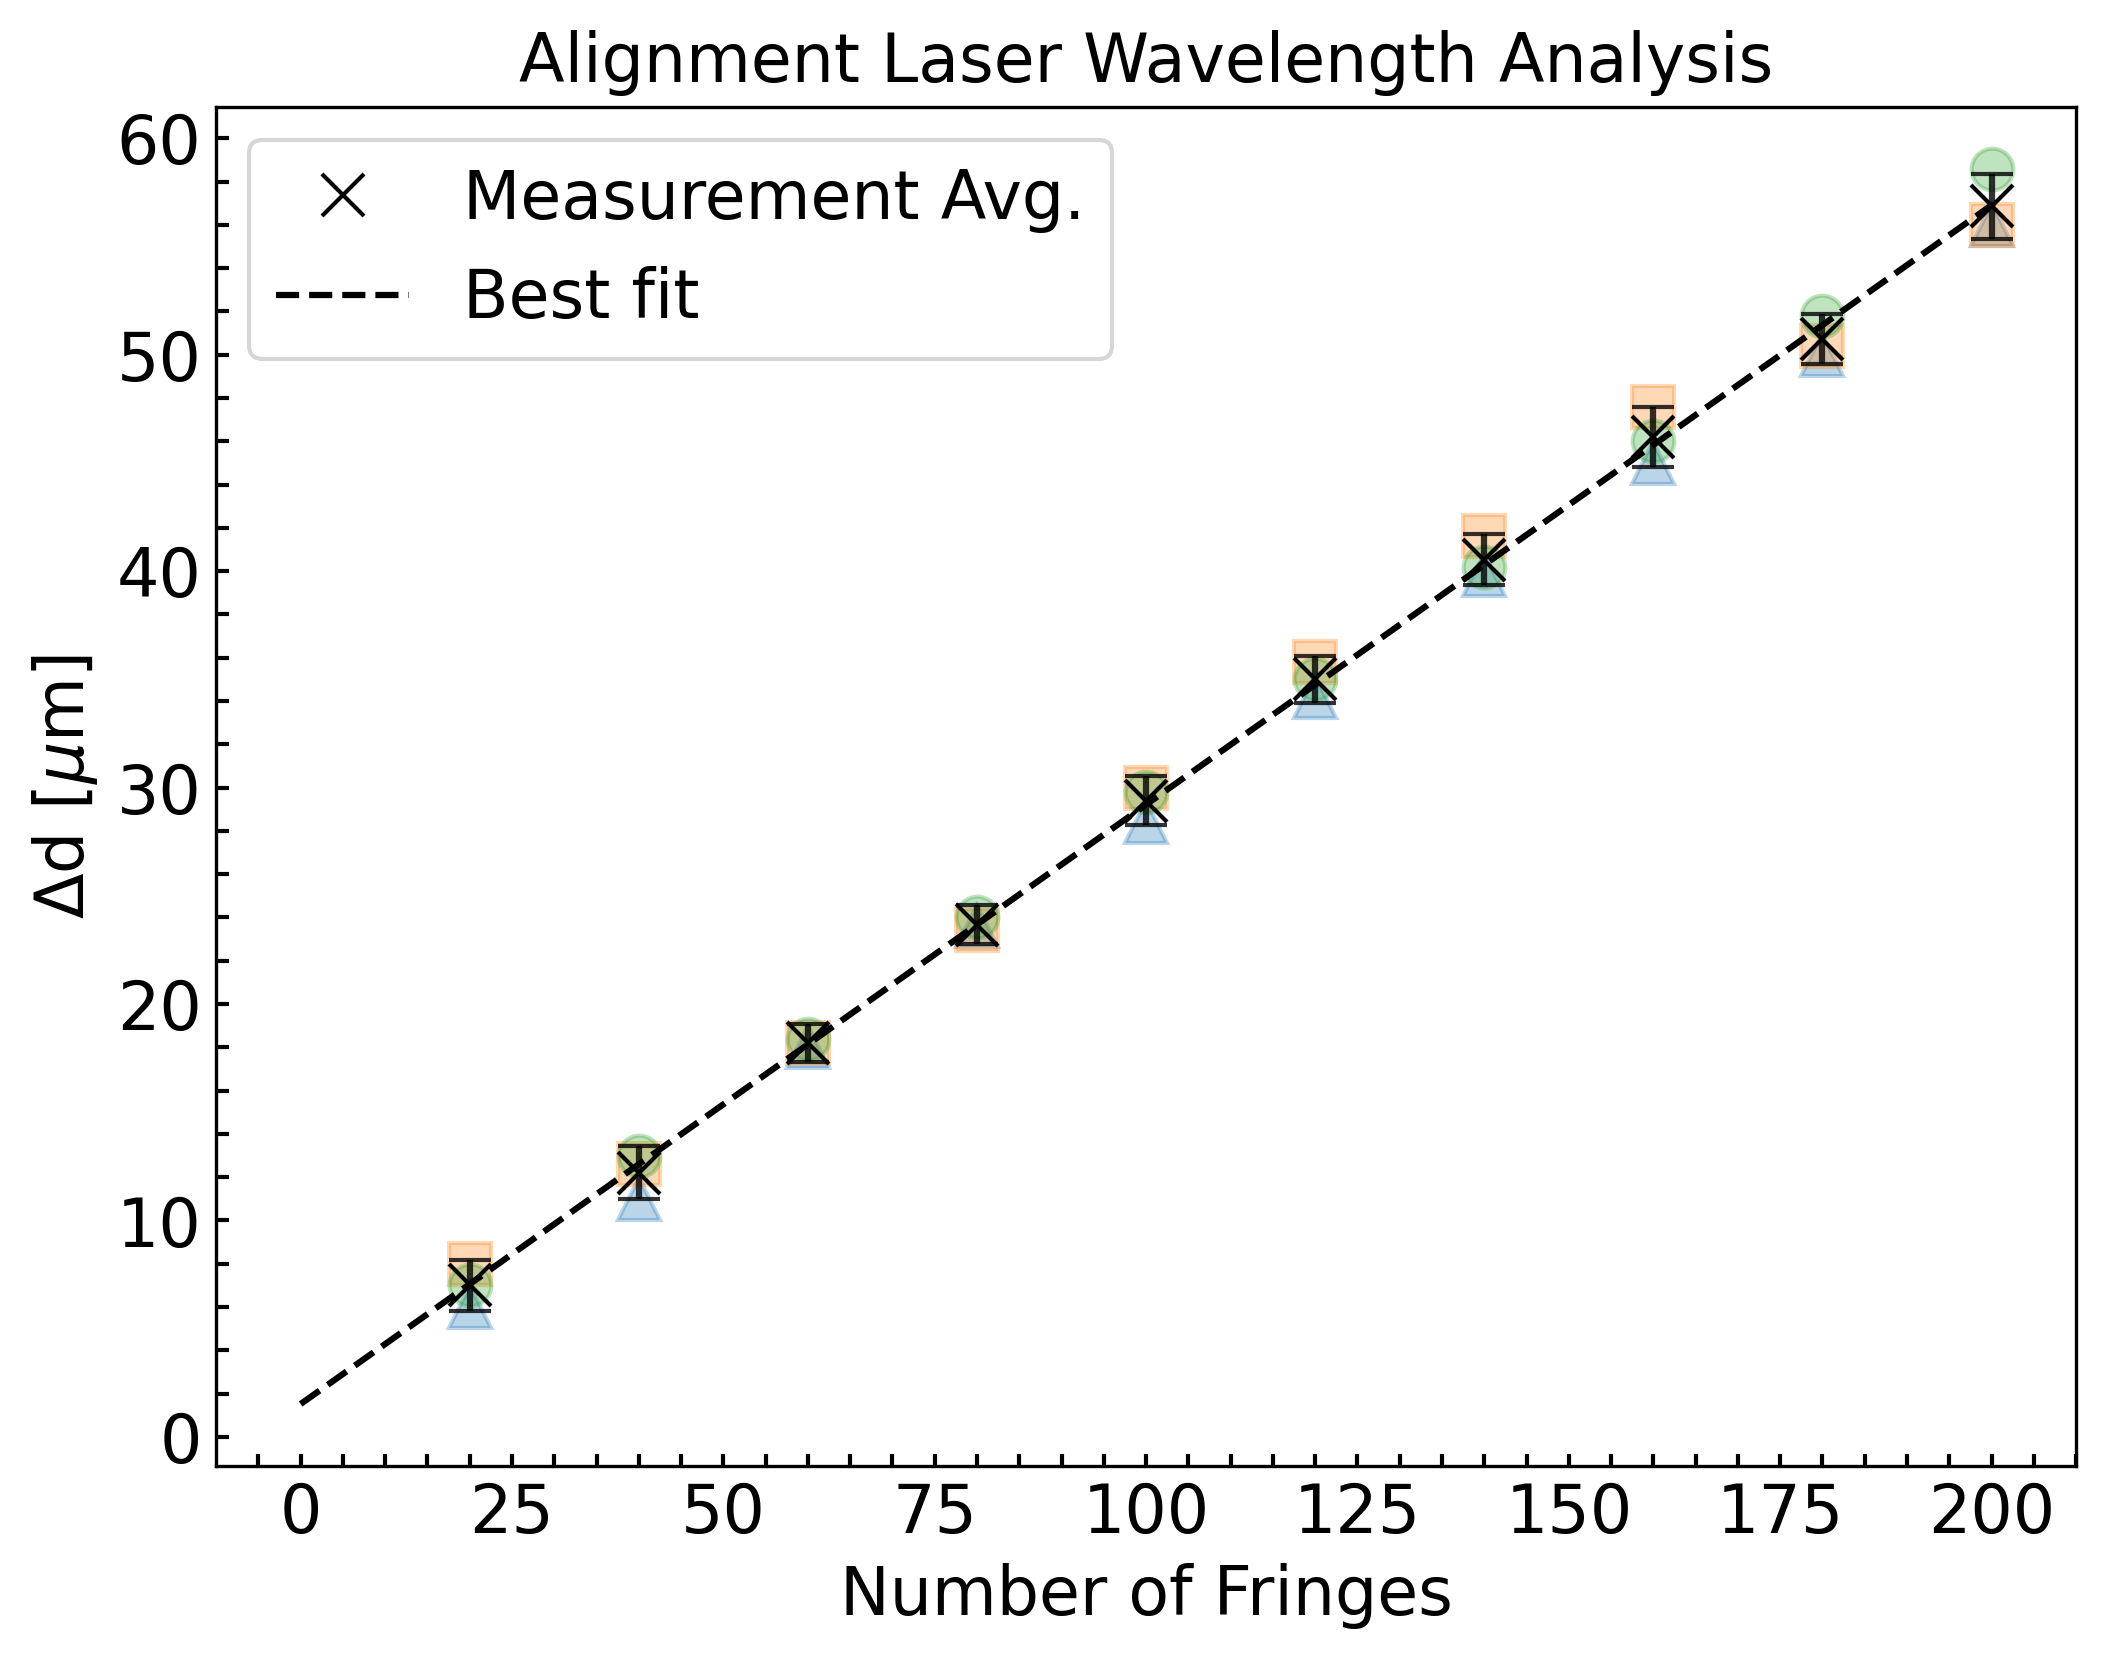

In [187]:
from scipy.optimize import curve_fit 

def f(x,m,b):
    return m * x + b

sigmas = np.sqrt(data_std**2. + sys_err**2.)    # add the systematic and measurement error in quadrate
popt, pcov = curve_fit(f, num_fringes-100, data_avg-30, sigma=sigmas)    # do the fit

fig = plt.figure(figsize=(8,6),dpi=300)
fs= 16

# plot the three measurement sets
plt.plot(num_fringes, dd_C, marker='^', markersize=10, ls='none', alpha=0.3)
plt.plot(num_fringes, dd_A, marker='s', markersize=10, ls='none', alpha=0.3)
plt.plot(num_fringes, dd_J, marker='o', markersize=10, ls='none', alpha=0.3)

# plot the avg and error
plt.plot(num_fringes, data_avg, marker='x', markersize=10, color='k', ls='none', label='Measurement Avg.')
plt.errorbar(num_fringes, data_avg, yerr=sigmas, capsize=5, color='k', ls='none', alpha=0.8)

# show the fit
xx = np.arange(0,210,10)
plt.plot(xx, popt[0] * (xx-100) + popt[1] + 30, c='k', label='Best fit', ls='--')

# style points
plt.xlabel('Number of Fringes', fontsize=fs)
plt.ylabel('$\Delta$d [$\mu$m]', fontsize=fs)
plt.title('Alignment Laser Wavelength Analysis',fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
ax = fig.gca()
ax.minorticks_on()
ax.tick_params(which='both',direction='in', length=3, width=1, color='k')
plt.legend(fontsize=fs)

# plt.savefig('Alignment_analysis.pdf',bbox_inches='tight')

In [188]:
# print best fit parameters and covariance
print(popt, pcov)

[ 0.2769231 -0.78524  ] [[ 3.44939891e-06 -4.11075136e-06]
 [-4.11075136e-06  9.53333725e-03]]


In [189]:
# calculate the wavelength and its error
wv = popt[0] * 2 * 1e3 
wv_err = np.sqrt(np.diag(pcov))[0]

print('The wavelength is', round(wv,4), '+/-', round(wv_err,4), 'nm')

The wavelength is 553.8462 +/- 0.0019 nm


In [190]:
# calculate the reduced chi2 of the fit
N = len(num_fringes)
Red_Chi2_me = 1.0/(N-2) * np.sum((data_avg - f(num_fringes, popt[0],popt[1]))**2 / sigmas**2)
print('Reduced Chi Squared= ', Red_Chi2_me)

Reduced Chi Squared=  5.398969878552256
